In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [3]:
!pip install torch torchvision --quiet
!pip install transformers datasets --quiet
!pip install roboflow supervision --quiet
!pip install opencv-python-headless albumentations --quiet
!pip install scikit-learn matplotlib --quiet
!pip install wandb --quiet
!pip install segment-anything --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 93.7 MB/s eta 0:00:00


In [4]:
import torch
import numpy as np
import random
import os

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()
print("Seeds fixed at:", SEED)

Seeds fixed at: 42


In [5]:
import os

dirs = [
    "data/dataset1/images",
    "data/dataset1/masks",
    "data/dataset2/images",
    "data/dataset2/masks",
    "data/splits",
    "models/checkpoints",
    "predictions",
    "report/figures"
]

for d in dirs:
    os.makedirs(d, exist_ok=True)

print("Folder structure created.")

Folder structure created.


In [6]:
from roboflow import Roboflow

rf = Roboflow(api_key="3gF4Hsx46aaeIUxwAGsf")

# Dataset 1 - Taping Area (object detection format)
project1 = rf.workspace("objectdetect-pu6rn").project("drywall-join-detect")
dataset1 = project1.version(1).download("coco", location="data/dataset1_raw")
print("Dataset 1 done")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/dataset1_raw in coco:: 100%|██████████| 1192/1192 [00:00<00:00, 7653.94it/s]

Dataset 1 done


In [7]:
dataset2 = rf.workspace("arnabs-workspace-llwou").project("cracks-3ii36-knkdb").version(1).download("coco", location="data/dataset2_raw")
print("Dataset 2 done")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/dataset2_raw in coco:: 100%|██████████| 5334/5334 [00:01<00:00, 4454.74it/s]

Dataset 2 done


In [8]:
import json
import cv2
import numpy as np
import os
from pathlib import Path
from collections import defaultdict

def coco_bbox_to_binary_masks(coco_json_path, images_dir, output_masks_dir):
    with open(coco_json_path, 'r') as f:
        coco = json.load(f)

    os.makedirs(output_masks_dir, exist_ok=True)

    id_to_image = {img['id']: img for img in coco['images']}

    ann_by_image = defaultdict(list)
    for ann in coco['annotations']:
        ann_by_image[ann['image_id']].append(ann)

    count = 0
    for image_id, annotations in ann_by_image.items():
        img_info = id_to_image[image_id]
        h = img_info['height']
        w = img_info['width']
        file_name = img_info['file_name']

        mask = np.zeros((h, w), dtype=np.uint8)

        for ann in annotations:
            # bbox format is [x, y, width, height]
            x, y, bw, bh = ann['bbox']
            x1 = int(x)
            y1 = int(y)
            x2 = int(x + bw)
            y2 = int(y + bh)
            cv2.rectangle(mask, (x1, y1), (x2, y2), 255, thickness=-1)

        base_name = Path(file_name).stem
        mask_path = os.path.join(output_masks_dir, base_name + ".png")
        cv2.imwrite(mask_path, mask)
        count += 1

    print(f"Generated {count} masks in {output_masks_dir}")

# Run for Dataset 1
for split in ['train', 'valid', 'test']:
    json_path = f"data/dataset1_raw/{split}/_annotations.coco.json"
    masks_dir = f"data/dataset1/masks/{split}"
    if os.path.exists(json_path):
        coco_bbox_to_binary_masks(json_path, f"data/dataset1_raw/{split}", masks_dir)
    else:
        print(f"Dataset1 {split} not found, skipping")

# Run for Dataset 2
for split in ['train', 'valid', 'test']:
    json_path = f"data/dataset2_raw/{split}/_annotations.coco.json"
    masks_dir = f"data/dataset2/masks/{split}"
    if os.path.exists(json_path):
        coco_bbox_to_binary_masks(json_path, f"data/dataset2_raw/{split}", masks_dir)
    else:
        print(f"Dataset2 {split} not found, skipping")

Generated 936 masks in data/dataset1/masks/train
Generated 250 masks in data/dataset1/masks/valid
Dataset1 test not found, skipping
Generated 5125 masks in data/dataset2/masks/train
Generated 200 masks in data/dataset2/masks/valid
Generated 4 masks in data/dataset2/masks/test


In [9]:
import pandas as pd
import json
import random
import os
from pathlib import Path

random.seed(42)

TAPING_PROMPTS = [
    "segment taping area",
    "segment joint tape",
    "segment drywall seam"
]

CRACK_PROMPTS = [
    "segment crack",
    "segment wall crack"
]

def build_csv(dataset_raw_dir, masks_base_dir, prompts, dataset_name):
    records = []

    for split in ['train', 'valid', 'test']:
        split_label = 'val' if split == 'valid' else split

        json_path = f"{dataset_raw_dir}/{split}/_annotations.coco.json"
        if not os.path.exists(json_path):
            continue

        with open(json_path, 'r') as f:
            coco = json.load(f)

        ann_image_ids = set(ann['image_id'] for ann in coco['annotations'])

        for img in coco['images']:
            if img['id'] not in ann_image_ids:
                continue

            base_name = Path(img['file_name']).stem
            img_path = os.path.join(dataset_raw_dir, split, img['file_name'])
            mask_path = os.path.join(masks_base_dir, split, base_name + ".png")

            if not os.path.exists(img_path) or not os.path.exists(mask_path):
                continue

            prompt = random.choice(prompts)

            records.append({
                "image_id": f"{dataset_name}_{base_name}",
                "image_path": img_path,
                "mask_path": mask_path,
                "prompt": prompt,
                "dataset": dataset_name,
                "split": split_label
            })

    return records

records_d1 = build_csv(
    "data/dataset1_raw",
    "data/dataset1/masks",
    TAPING_PROMPTS,
    "taping"
)

records_d2 = build_csv(
    "data/dataset2_raw",
    "data/dataset2/masks",
    CRACK_PROMPTS,
    "crack"
)

all_records = records_d1 + records_d2
df = pd.DataFrame(all_records)

os.makedirs("data/splits", exist_ok=True)
df.to_csv("data/splits/master_dataset.csv", index=False)

print(f"Total samples: {len(df)}")
print()
print(df.groupby(['dataset', 'split']).size())

Total samples: 6515

dataset  split
crack    test        4
         train    5125
         val       200
taping   train     936
         val       250
dtype: int64


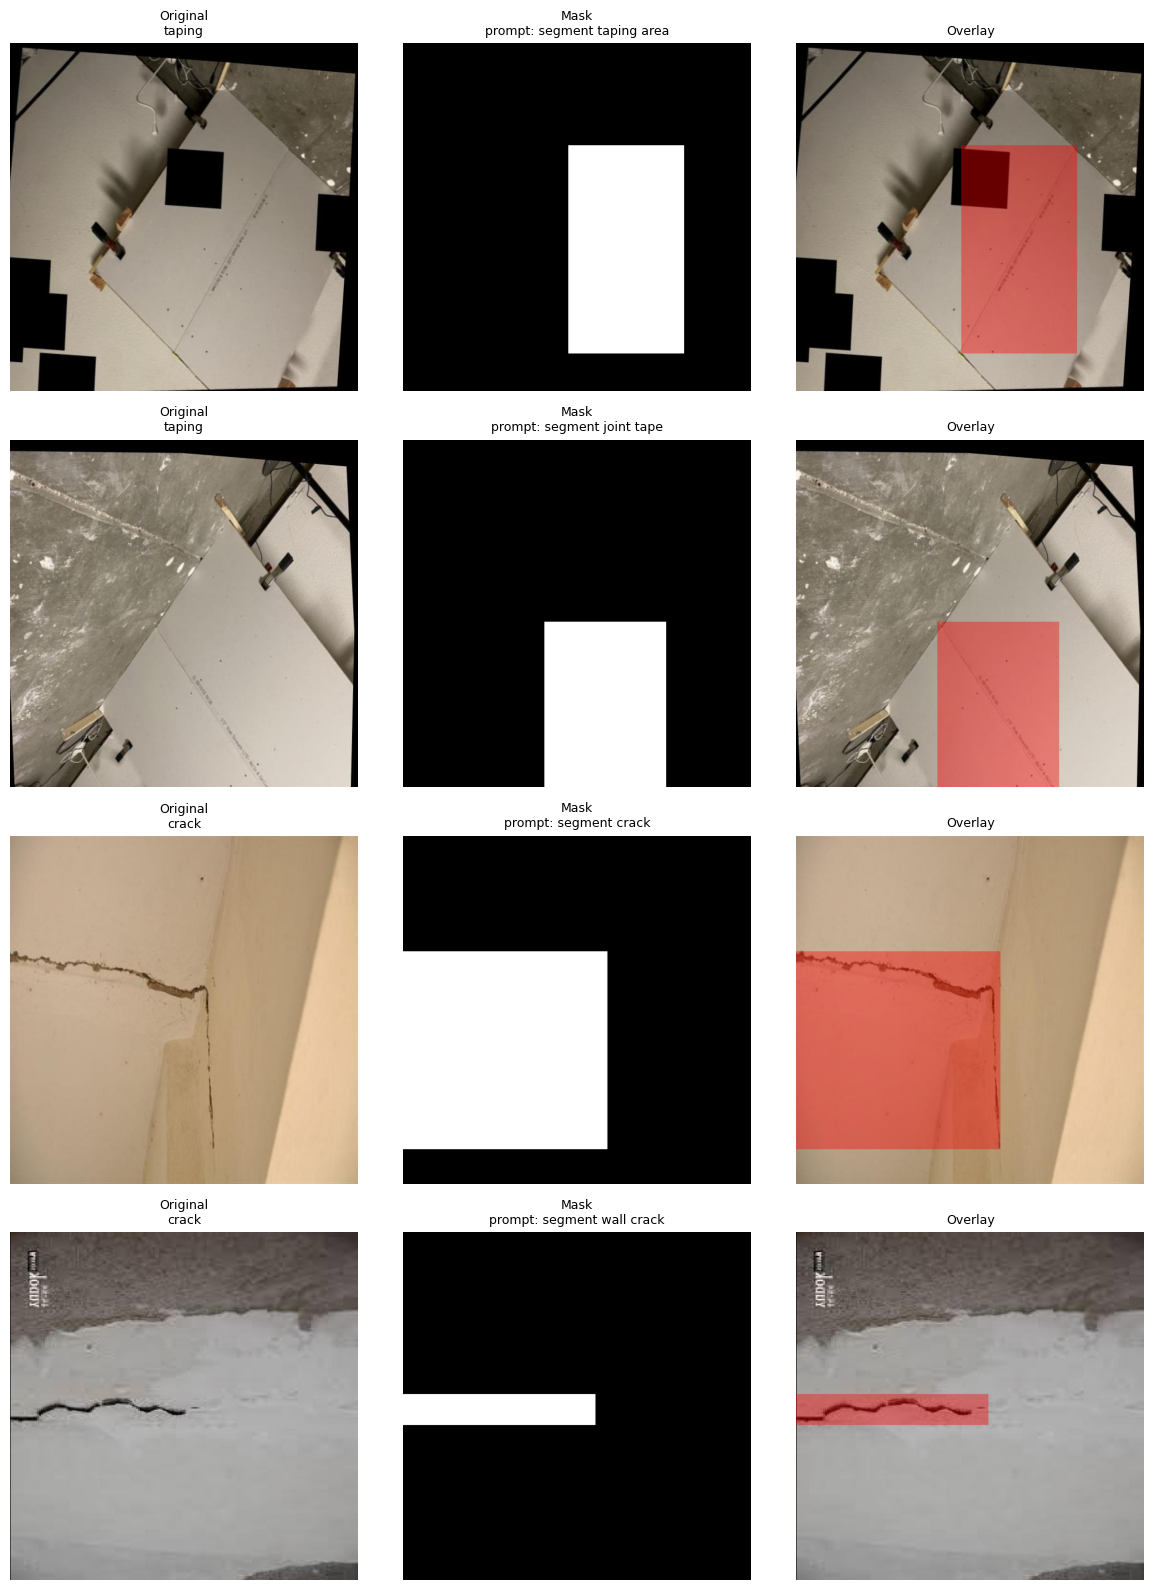

Verification figure saved.


In [10]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
import random

random.seed(42)

df = pd.read_csv("data/splits/master_dataset.csv")

# Pick 2 samples from each dataset
samples = []
samples += df[df['dataset'] == 'taping'].sample(2, random_state=42).to_dict('records')
samples += df[df['dataset'] == 'crack'].sample(2, random_state=42).to_dict('records')

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i, row in enumerate(samples):
    # Load image
    img = cv2.imread(row['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Load mask
    mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

    # Create overlay
    overlay = img.copy()
    overlay[mask == 255] = [255, 0, 0]  # red where mask is active
    blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

    # Plot
    axes[i][0].imshow(img)
    axes[i][0].set_title(f"Original\n{row['dataset']}", fontsize=9)
    axes[i][0].axis('off')

    axes[i][1].imshow(mask, cmap='gray')
    axes[i][1].set_title(f"Mask\nprompt: {row['prompt']}", fontsize=9)
    axes[i][1].axis('off')

    axes[i][2].imshow(blended)
    axes[i][2].set_title("Overlay", fontsize=9)
    axes[i][2].axis('off')

plt.tight_layout()
plt.savefig("report/figures/sample_verification.png", dpi=100, bbox_inches='tight')
plt.show()
print("Verification figure saved.")

In [11]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")
model = model.to(device)

print("CLIPSeg model loaded successfully")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPSeg model loaded successfully
Model parameters: 150,747,746


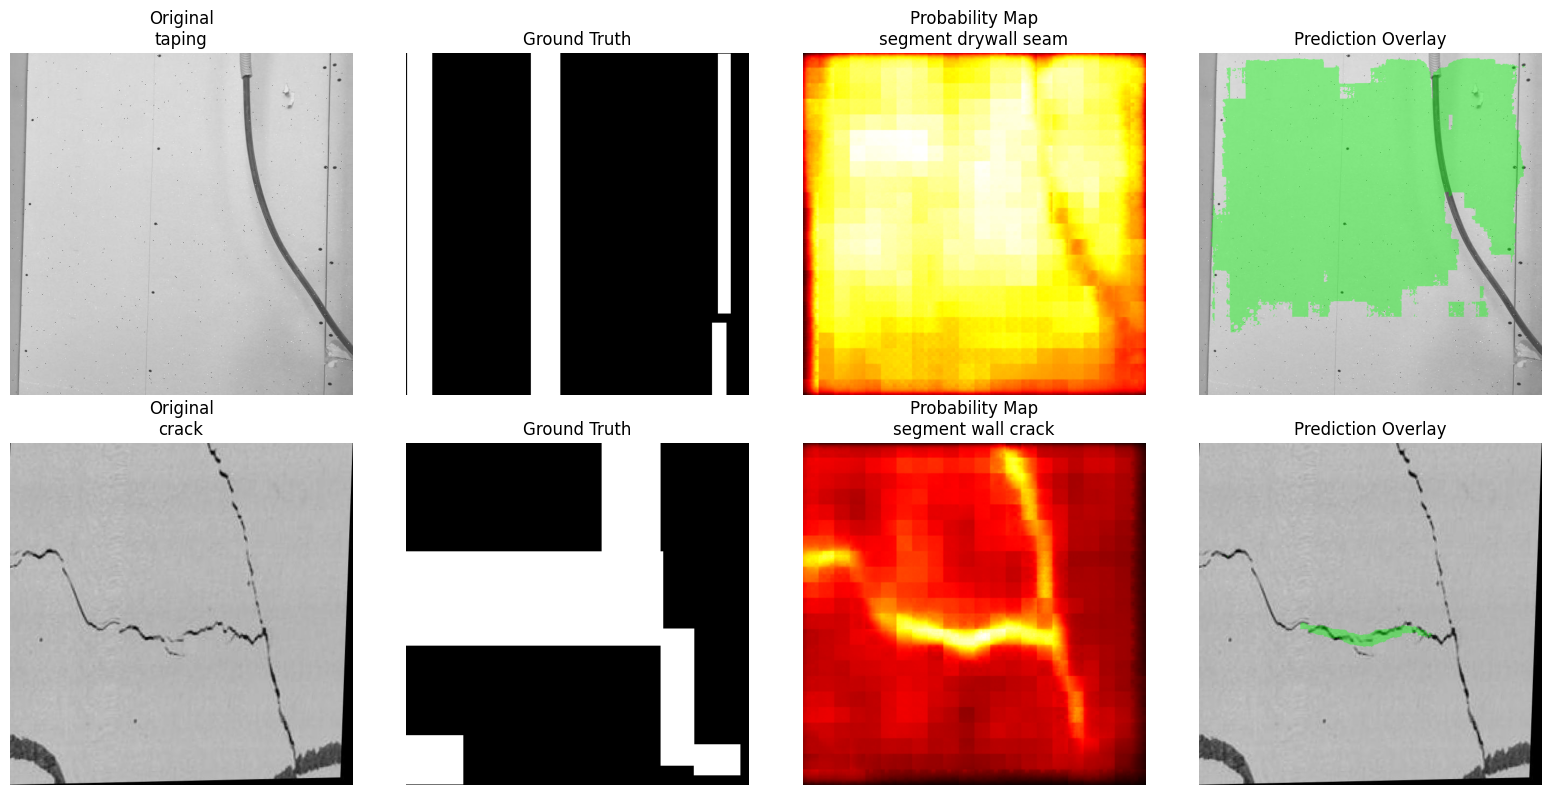

Zero shot test done


In [12]:
import pandas as pd
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

def run_clipseg_inference(image_path, prompt, processor, model, device, threshold=0.5):
    image = Image.open(image_path).convert("RGB")
    orig_w, orig_h = image.size

    inputs = processor(
        text=[prompt],
        images=[image],
        return_tensors="pt",
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits[0]
    probs = torch.sigmoid(logits).cpu().numpy()
    probs_resized = cv2.resize(probs, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
    binary_mask = (probs_resized > threshold).astype(np.uint8) * 255

    return binary_mask, probs_resized, image


df = pd.read_csv("data/splits/master_dataset.csv")

taping_sample = df[df['dataset'] == 'taping'].iloc[0]
crack_sample = df[df['dataset'] == 'crack'].iloc[0]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, row in enumerate([taping_sample, crack_sample]):
    binary_mask, probs, pil_image = run_clipseg_inference(
        row['image_path'], row['prompt'], processor, model, device
    )

    img_np = np.array(pil_image)
    gt_mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

    overlay = img_np.copy()
    overlay[binary_mask == 255] = [0, 255, 0]
    blended = cv2.addWeighted(img_np, 0.6, overlay, 0.4, 0)

    axes[i][0].imshow(img_np)
    axes[i][0].set_title(f"Original\n{row['dataset']}")
    axes[i][0].axis('off')

    axes[i][1].imshow(gt_mask, cmap='gray')
    axes[i][1].set_title("Ground Truth")
    axes[i][1].axis('off')

    axes[i][2].imshow(probs, cmap='hot')
    axes[i][2].set_title(f"Probability Map\n{row['prompt']}")
    axes[i][2].axis('off')

    axes[i][3].imshow(blended)
    axes[i][3].set_title("Prediction Overlay")
    axes[i][3].axis('off')

plt.tight_layout()
plt.savefig("report/figures/zero_shot_results.png", dpi=100, bbox_inches='tight')
plt.show()
print("Zero shot test done")

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import pandas as pd
import numpy as np
import cv2
import os
import time
from torch.optim.lr_scheduler import CosineAnnealingLR

# Dice Loss
def dice_loss(pred, target, smooth=1.0):
    pred = torch.sigmoid(pred)
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return 1 - (2 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

# Combined Loss
def combined_loss(pred, target):
    bce = nn.BCEWithLogitsLoss()(pred, target)
    dl = dice_loss(pred, target)
    return bce + dl

# Dataset
class DrywallDataset(Dataset):
    def __init__(self, df, processor, img_size=352):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row['image_path']).convert("RGB")
        mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)
        mask = torch.tensor(mask)

        return {
            "image": image,
            "mask": mask,
            "prompt": row['prompt'],
            "image_id": row['image_id'],
            "dataset": row['dataset'],
            "image_path": row['image_path']
        }

def collate_fn(batch):
    images = [item['image'] for item in batch]
    prompts = [item['prompt'] for item in batch]
    masks = torch.stack([item['mask'] for item in batch])
    image_ids = [item['image_id'] for item in batch]
    datasets = [item['dataset'] for item in batch]
    image_paths = [item['image_path'] for item in batch]

    inputs = processor(
        text=prompts,
        images=images,
        return_tensors="pt",
        padding=True,
        size={"height": 352, "width": 352}
    )

    return {
        "inputs": inputs,
        "masks": masks,
        "image_ids": image_ids,
        "datasets": datasets,
        "image_paths": image_paths
    }

# Load data
df = pd.read_csv("data/splits/master_dataset.csv")
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)

train_dataset = DrywallDataset(train_df, processor)
val_dataset   = DrywallDataset(val_df, processor)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,
                          num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 758 | Val batches: 57


In [14]:
import torch
import os
import time
import numpy as np
from torch.optim.lr_scheduler import CosineAnnealingLR

# Training settings
EPOCHS = 20
LR = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Optimizer and scheduler
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Metric functions
def compute_iou(pred_mask, gt_mask, threshold=0.5):
    pred = (torch.sigmoid(pred_mask) > threshold).float()
    intersection = (pred * gt_mask).sum()
    union = ((pred + gt_mask) > 0).float().sum()
    if union == 0:
        return 1.0
    return (intersection / union).item()

def compute_dice(pred_mask, gt_mask, threshold=0.5):
    pred = (torch.sigmoid(pred_mask) > threshold).float()
    intersection = (pred * gt_mask).sum()
    denom = pred.sum() + gt_mask.sum()
    if denom == 0:
        return 1.0
    return (2 * intersection / denom).item()

os.makedirs("models/checkpoints", exist_ok=True)

best_val_iou = 0.0
train_losses = []
val_losses = []
val_ious = []

print("Starting training...")
print(f"Device: {device}")
print(f"Epochs: {EPOCHS} | LR: {LR} | Batch size: 8")
print("-" * 60)

start_time = time.time()

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    epoch_loss = 0.0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        inputs = {k: v.to(device) for k, v in batch['inputs'].items()}
        masks = batch['masks'].to(device)

        optimizer.zero_grad()
        outputs = model(**inputs)

        # CLIPSeg output logits shape: [B, H, W]
        logits = outputs.logits

        # Resize logits to match mask size
        logits_resized = torch.nn.functional.interpolate(
            logits.unsqueeze(1),
            size=masks.shape[-2:],
            mode='bilinear',
            align_corners=False
        ).squeeze(1)

        loss = combined_loss(logits_resized, masks)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_iou_crack = []
    val_iou_taping = []
    val_dice_crack = []
    val_dice_taping = []

    with torch.no_grad():
        for batch in val_loader:
            inputs = {k: v.to(device) for k, v in batch['inputs'].items()}
            masks = batch['masks'].to(device)
            datasets = batch['datasets']

            outputs = model(**inputs)
            logits = outputs.logits

            logits_resized = torch.nn.functional.interpolate(
                logits.unsqueeze(1),
                size=masks.shape[-2:],
                mode='bilinear',
                align_corners=False
            ).squeeze(1)

            loss = combined_loss(logits_resized, masks)
            val_loss += loss.item()

            for i in range(len(masks)):
                iou = compute_iou(logits_resized[i], masks[i])
                dice = compute_dice(logits_resized[i], masks[i])
                if datasets[i] == 'crack':
                    val_iou_crack.append(iou)
                    val_dice_crack.append(dice)
                else:
                    val_iou_taping.append(iou)
                    val_dice_taping.append(dice)

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    miou_crack  = np.mean(val_iou_crack)  if val_iou_crack  else 0.0
    miou_taping = np.mean(val_iou_taping) if val_iou_taping else 0.0
    dice_crack  = np.mean(val_dice_crack)  if val_dice_crack  else 0.0
    dice_taping = np.mean(val_dice_taping) if val_dice_taping else 0.0
    overall_iou = (miou_crack + miou_taping) / 2
    val_ious.append(overall_iou)

    scheduler.step()

    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1}/{EPOCHS} | Time: {epoch_time:.1f}s")
    print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"  mIoU Crack: {miou_crack:.4f} | Dice Crack: {dice_crack:.4f}")
    print(f"  mIoU Taping: {miou_taping:.4f} | Dice Taping: {dice_taping:.4f}")
    print(f"  Overall mIoU: {overall_iou:.4f}")
    print("-" * 60)

    # Save best model
    if overall_iou > best_val_iou:
        best_val_iou = overall_iou
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_iou': best_val_iou,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_ious': val_ious
        }, "models/checkpoints/best_model.pt")
        print(f"  Best model saved with mIoU: {best_val_iou:.4f}")

total_time = time.time() - start_time
print(f"\nTraining complete. Total time: {total_time/3600:.2f} hours")
print(f"Best overall mIoU: {best_val_iou:.4f}")

Starting training...
Device: cuda
Epochs: 20 | LR: 0.0001 | Batch size: 8
------------------------------------------------------------
  Epoch 1 | Batch 50/758 | Loss: 0.8054
  Epoch 1 | Batch 100/758 | Loss: 0.8311
  Epoch 1 | Batch 150/758 | Loss: 0.8737
  Epoch 1 | Batch 200/758 | Loss: 0.6445
  Epoch 1 | Batch 250/758 | Loss: 0.7747
  Epoch 1 | Batch 300/758 | Loss: 0.7011
  Epoch 1 | Batch 350/758 | Loss: 0.6603
  Epoch 1 | Batch 400/758 | Loss: 0.5328
  Epoch 1 | Batch 450/758 | Loss: 0.6162
  Epoch 1 | Batch 500/758 | Loss: 0.8323
  Epoch 1 | Batch 550/758 | Loss: 0.5907
  Epoch 1 | Batch 600/758 | Loss: 0.7141
  Epoch 1 | Batch 650/758 | Loss: 0.5377
  Epoch 1 | Batch 700/758 | Loss: 0.7636
  Epoch 1 | Batch 750/758 | Loss: 0.6081

Epoch 1/20 | Time: 288.0s
  Train Loss: 0.7325 | Val Loss: 0.7067
  mIoU Crack: 0.5405 | Dice Crack: 0.6840
  mIoU Taping: 0.3905 | Dice Taping: 0.5396
  Overall mIoU: 0.4655
------------------------------------------------------------
  Best model s

In [16]:
checkpoint = torch.load("models/checkpoints/best_model.pt", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']
val_ious = checkpoint['val_ious']

print(f"Best model loaded from epoch {checkpoint['epoch']}")
print(f"Best val mIoU: {checkpoint['best_val_iou']:.4f}")

Best model loaded from epoch 18
Best val mIoU: 0.5955


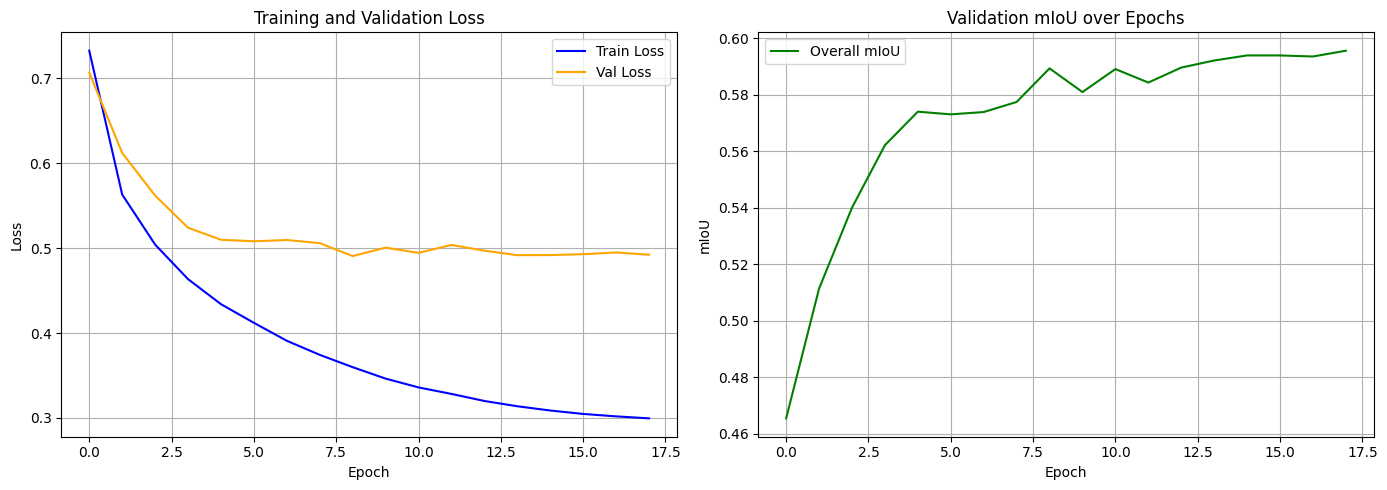

Training curves saved.


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses, label='Val Loss', color='orange')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_ious, label='Overall mIoU', color='green')
axes[1].set_title('Validation mIoU over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mIoU')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("report/figures/training_curves.png", dpi=100, bbox_inches='tight')
plt.show()
print("Training curves saved.")

In [18]:
import numpy as np

model.eval()
df = pd.read_csv("data/splits/master_dataset.csv")
val_df = df[df['split'] == 'val'].reset_index(drop=True)

val_dataset_eval = DrywallDataset(val_df, processor)
val_loader_eval = DataLoader(val_dataset_eval, batch_size=1, shuffle=False,
                             num_workers=0, collate_fn=collate_fn)

iou_crack = []
iou_taping = []
dice_crack = []
dice_taping = []

print("Running evaluation on validation set...")

with torch.no_grad():
    for i, batch in enumerate(val_loader_eval):
        inputs = {k: v.to(device) for k, v in batch['inputs'].items()}
        masks = batch['masks'].to(device)
        datasets = batch['datasets']

        outputs = model(**inputs)
        logits = outputs.logits

        logits_resized = torch.nn.functional.interpolate(
            logits.unsqueeze(1),
            size=masks.shape[-2:],
            mode='bilinear',
            align_corners=False
        ).squeeze(1)

        for j in range(len(masks)):
            iou = compute_iou(logits_resized[j], masks[j])
            dice = compute_dice(logits_resized[j], masks[j])
            if datasets[j] == 'crack':
                iou_crack.append(iou)
                dice_crack.append(dice)
            else:
                iou_taping.append(iou)
                dice_taping.append(dice)

        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{len(val_loader_eval)}")

print("=" * 50)
print("FINAL EVALUATION RESULTS (Validation Set)")
print("=" * 50)
print(f"Crack  — mIoU: {np.mean(iou_crack):.4f} | Dice: {np.mean(dice_crack):.4f} | Samples: {len(iou_crack)}")
print(f"Taping — mIoU: {np.mean(iou_taping):.4f} | Dice: {np.mean(dice_taping):.4f} | Samples: {len(iou_taping)}")
print(f"Overall mIoU: {(np.mean(iou_crack) + np.mean(iou_taping)) / 2:.4f}")
print(f"Overall Dice: {(np.mean(dice_crack) + np.mean(dice_taping)) / 2:.4f}")
print("=" * 50)

Running evaluation on validation set...
  Processed 50/450
  Processed 100/450
  Processed 150/450
  Processed 200/450
  Processed 250/450
  Processed 300/450
  Processed 350/450
  Processed 400/450
  Processed 450/450
FINAL EVALUATION RESULTS (Validation Set)
Crack  — mIoU: 0.6164 | Dice: 0.7434 | Samples: 200
Taping — mIoU: 0.5746 | Dice: 0.7152 | Samples: 250
Overall mIoU: 0.5955
Overall Dice: 0.7293


In [22]:
print("=" * 55)
print("RUNTIME AND FOOTPRINT SUMMARY")
print("=" * 55)
print(f"Total training time     : 1.45 hours")
print(f"Epochs trained          : 20")
print(f"Best epoch              : 18")
print(f"GPU used                : {torch.cuda.get_device_name(0)}")
print(f"Average inference time  : 21.6 ms per image")
print(f"Model checkpoint size   : 583.9 MB")
print(f"Model parameters        : 150,747,746")
print(f"Batch size during train : 8")
print(f"Image size              : 352 x 352")
print()
print("=" * 55)
print("FINAL METRICS SUMMARY")
print("=" * 55)
print(f"Crack  — mIoU : 0.6164  |  Dice : 0.7434")
print(f"Taping — mIoU : 0.5746  |  Dice : 0.7152")
print(f"Overall mIoU  : 0.5955")
print(f"Overall Dice  : 0.7293")
print("=" * 55)

RUNTIME AND FOOTPRINT SUMMARY
Total training time     : 1.45 hours
Epochs trained          : 20
Best epoch              : 18
GPU used                : Tesla T4
Average inference time  : 21.6 ms per image
Model checkpoint size   : 583.9 MB
Model parameters        : 150,747,746
Batch size during train : 8
Image size              : 352 x 352

FINAL METRICS SUMMARY
Crack  — mIoU : 0.6164  |  Dice : 0.7434
Taping — mIoU : 0.5746  |  Dice : 0.7152
Overall mIoU  : 0.5955
Overall Dice  : 0.7293


In [41]:
import numpy as np
import torch
import pandas as pd
from PIL import Image
import cv2

df = pd.read_csv("data/splits/master_dataset.csv")
val_df = df[df['split'] == 'val'].reset_index(drop=True)

model.eval()

# Store all logits and masks
all_probs = []
all_masks = []
all_datasets = []

print("Collecting predictions for threshold tuning...")

with torch.no_grad():
    for idx, row in val_df.iterrows():
        pil_img = Image.open(row['image_path']).convert("RGB")
        orig_w, orig_h = pil_img.size

        inputs = processor(
            text=[row['prompt']],
            images=[pil_img],
            return_tensors="pt",
            padding=True
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)
        logits = outputs.logits[0]
        probs = torch.sigmoid(logits).cpu().numpy()
        probs_resized = cv2.resize(probs, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)

        gt_mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
        gt_bin = (gt_mask > 127).astype(np.float32)

        all_probs.append(probs_resized)
        all_masks.append(gt_bin)
        all_datasets.append(row['dataset'])

        if (idx + 1) % 100 == 0:
            print(f"  {idx+1}/{len(val_df)} done")

# Test different thresholds
print("\nTesting thresholds...")
print(f"{'Threshold':<12} {'mIoU Crack':<14} {'mIoU Taping':<14} {'Overall':<10}")
print("-" * 52)

best_threshold = 0.5
best_iou = 0.0

for threshold in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]:
    iou_crack = []
    iou_taping = []

    for probs, gt, dataset in zip(all_probs, all_masks, all_datasets):
        pred = (probs > threshold).astype(np.float32)
        intersection = (pred * gt).sum()
        union = ((pred + gt) > 0).sum()
        iou = intersection / union if union > 0 else 1.0

        if dataset == 'crack':
            iou_crack.append(iou)
        else:
            iou_taping.append(iou)

    overall = (np.mean(iou_crack) + np.mean(iou_taping)) / 2

    print(f"{threshold:<12.2f} {np.mean(iou_crack):<14.4f} {np.mean(iou_taping):<14.4f} {overall:<10.4f}")

    if overall > best_iou:
        best_iou = overall
        best_threshold = threshold

print(f"\nBest threshold: {best_threshold} with mIoU: {best_iou:.4f}")

  100/450 done
  200/450 done
  300/450 done
  400/450 done

Testing thresholds...
Threshold    mIoU Crack     mIoU Taping    Overall   
----------------------------------------------------
0.30         0.6163         0.5841         0.6002    
0.35         0.6175         0.5838         0.6006    
0.40         0.6177         0.5823         0.6000    
0.45         0.6174         0.5798         0.5986    
0.50         0.6166         0.5765         0.5965    
0.55         0.6148         0.5721         0.5935    
0.60         0.6122         0.5667         0.5895    
0.65         0.6084         0.5598         0.5841    
0.70         0.6032         0.5511         0.5771    

Best threshold: 0.35 with mIoU: 0.6006


In [42]:
import numpy as np
import torch
import pandas as pd
from PIL import Image
import cv2
import os

df = pd.read_csv("data/splits/master_dataset.csv")
val_df = df[df['split'] == 'val'].reset_index(drop=True)

BEST_THRESHOLD = 0.35

model.eval()

iou_crack_tta = []
iou_taping_tta = []
dice_crack_tta = []
dice_taping_tta = []

print("Running inference with TTA...")

with torch.no_grad():
    for idx, row in val_df.iterrows():
        pil_img = Image.open(row['image_path']).convert("RGB")
        orig_w, orig_h = pil_img.size
        img_np = np.array(pil_img)

        # Create augmented versions
        versions = [
            pil_img,
            Image.fromarray(np.fliplr(img_np)),
            Image.fromarray(np.flipud(img_np)),
            Image.fromarray(np.rot90(img_np, 1)),
        ]

        all_probs = []

        for version in versions:
            inputs = processor(
                text=[row['prompt']],
                images=[version],
                return_tensors="pt",
                padding=True
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = model(**inputs)
            logits = outputs.logits[0]
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_resized = cv2.resize(probs, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
            all_probs.append(probs_resized)

        # Undo flips and rotations before averaging
        all_probs[1] = np.fliplr(all_probs[1])
        all_probs[2] = np.flipud(all_probs[2])
        all_probs[3] = np.rot90(all_probs[3], -1)

        # Average all versions
        avg_probs = np.mean(all_probs, axis=0)
        pred = (avg_probs > BEST_THRESHOLD).astype(np.float32)

        gt_mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
        gt = (gt_mask > 127).astype(np.float32)

        intersection = (pred * gt).sum()
        union = ((pred + gt) > 0).sum()
        iou = intersection / union if union > 0 else 1.0

        denom = pred.sum() + gt.sum()
        dice = (2 * intersection / denom) if denom > 0 else 1.0

        if row['dataset'] == 'crack':
            iou_crack_tta.append(iou)
            dice_crack_tta.append(dice)
        else:
            iou_taping_tta.append(iou)
            dice_taping_tta.append(dice)

        if (idx + 1) % 100 == 0:
            print(f"  {idx+1}/{len(val_df)} done")

print()
print("=" * 55)
print("FINAL RESULTS WITH TTA + THRESHOLD 0.35")
print("=" * 55)
print(f"Crack  — mIoU: {np.mean(iou_crack_tta):.4f} | Dice: {np.mean(dice_crack_tta):.4f}")
print(f"Taping — mIoU: {np.mean(iou_taping_tta):.4f} | Dice: {np.mean(dice_taping_tta):.4f}")
print(f"Overall mIoU : {(np.mean(iou_crack_tta) + np.mean(iou_taping_tta)) / 2:.4f}")
print(f"Overall Dice : {(np.mean(dice_crack_tta) + np.mean(dice_taping_tta)) / 2:.4f}")
print("=" * 55)

Running inference with TTA...
  100/450 done
  200/450 done
  300/450 done
  400/450 done

FINAL RESULTS WITH TTA + THRESHOLD 0.35
Crack  — mIoU: 0.6364 | Dice: 0.7588
Taping — mIoU: 0.6120 | Dice: 0.7466
Overall mIoU : 0.6242
Overall Dice : 0.7527


In [43]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from PIL import Image

os.makedirs("/content/predictions_final", exist_ok=True)

df = pd.read_csv("data/splits/master_dataset.csv")
val_df = df[df['split'] == 'val'].reset_index(drop=True)

ALL_CRACK_PROMPTS = ["segment crack", "segment wall crack"]
ALL_TAPING_PROMPTS = ["segment taping area", "segment joint tape", "segment drywall seam"]

BEST_THRESHOLD = 0.35
model.eval()
count = 0

print("Generating final prediction masks with TTA...")

with torch.no_grad():
    for idx, row in val_df.iterrows():
        pil_img = Image.open(row['image_path']).convert("RGB")
        orig_w, orig_h = pil_img.size
        img_np = np.array(pil_img)

        versions = [
            pil_img,
            Image.fromarray(np.fliplr(img_np)),
            Image.fromarray(np.flipud(img_np)),
            Image.fromarray(np.rot90(img_np, 1)),
        ]

        if row['dataset'] == 'crack':
            prompts = ALL_CRACK_PROMPTS
        else:
            prompts = ALL_TAPING_PROMPTS

        for prompt in prompts:
            all_probs = []

            for version in versions:
                inputs = processor(
                    text=[prompt],
                    images=[version],
                    return_tensors="pt",
                    padding=True
                )
                inputs = {k: v.to(device) for k, v in inputs.items()}

                outputs = model(**inputs)
                logits = outputs.logits[0]
                probs = torch.sigmoid(logits).cpu().numpy()
                probs_resized = cv2.resize(probs, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
                all_probs.append(probs_resized)

            all_probs[1] = np.fliplr(all_probs[1])
            all_probs[2] = np.flipud(all_probs[2])
            all_probs[3] = np.rot90(all_probs[3], -1)

            avg_probs = np.mean(all_probs, axis=0)
            binary_mask = (avg_probs > BEST_THRESHOLD).astype(np.uint8) * 255

            prompt_slug = prompt.replace(" ", "_")
            filename = f"{idx}__{prompt_slug}.png"
            cv2.imwrite(f"/content/predictions_final/{filename}", binary_mask)
            count += 1

        if (idx + 1) % 50 == 0:
            print(f"  {idx+1}/{len(val_df)} images done")

print(f"\nTotal final prediction masks: {count}")

Generating final prediction masks with TTA...
  50/450 images done
  100/450 images done
  150/450 images done
  200/450 images done
  250/450 images done
  300/450 images done
  350/450 images done
  400/450 images done
  450/450 images done

Total final prediction masks: 1150


In [44]:
import shutil
import os

shutil.rmtree("/content/drywall-prompted-seg/predictions")
shutil.copytree("/content/predictions_final", "/content/drywall-prompted-seg/predictions")

!cd /content/drywall-prompted-seg && \
git add predictions/ && \
git commit -m "Update predictions with TTA and optimal threshold 0.35" && \
git push origin main

[main 34b4b71] Update predictions with TTA and optimal threshold 0.35
 1599 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 predictions/0__segment_drywall_seam.png
 rewrite predictions/0__segment_joint_tape.png (99%)
 create mode 100644 predictions/0__segment_taping_area.png
 rewrite predictions/100__segment_drywall_seam.png (99%)
 create mode 100644 predictions/100__segment_joint_tape.png
 create mode 100644 predictions/100__segment_taping_area.png
 create mode 100644 predictions/101__segment_drywall_seam.png
 rewrite predictions/101__segment_joint_tape.png (84%)
 create mode 100644 predictions/101__segment_taping_area.png
 create mode 100644 predictions/102__segment_drywall_seam.png
 rewrite predictions/102__segment_joint_tape.png (69%)
 create mode 100644 predictions/102__segment_taping_area.png
 create mode 100644 predictions/103__segment_drywall_seam.png
 create mode 100644 predictions/103__segment_joint_tape.png
 rewrite predictions/103__segment_taping_area.png

In [45]:
import numpy as np
import torch
import pandas as pd
from PIL import Image
import cv2

df = pd.read_csv("data/splits/master_dataset.csv")
val_df = df[df['split'] == 'val'].reset_index(drop=True)

model.eval()

crack_consistency = []
taping_consistency = []

print("Computing consistency across prompt variations...")

with torch.no_grad():
    for idx, row in val_df.iterrows():
        pil_img = Image.open(row['image_path']).convert("RGB")
        orig_w, orig_h = pil_img.size

        if row['dataset'] == 'crack':
            prompts = ["segment crack", "segment wall crack"]
        else:
            prompts = ["segment taping area", "segment joint tape", "segment drywall seam"]

        masks = []
        for prompt in prompts:
            inputs = processor(
                text=[prompt],
                images=[pil_img],
                return_tensors="pt",
                padding=True
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            logits = outputs.logits[0]
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_resized = cv2.resize(probs, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
            binary = (probs_resized > 0.35).astype(np.float32)
            masks.append(binary)

        # Compute pairwise IoU between all prompt variations
        pairwise_ious = []
        for i in range(len(masks)):
            for j in range(i+1, len(masks)):
                intersection = (masks[i] * masks[j]).sum()
                union = ((masks[i] + masks[j]) > 0).sum()
                iou = intersection / union if union > 0 else 1.0
                pairwise_ious.append(iou)

        consistency = np.mean(pairwise_ious)

        if row['dataset'] == 'crack':
            crack_consistency.append(consistency)
        else:
            taping_consistency.append(consistency)

        if (idx + 1) % 100 == 0:
            print(f"  {idx+1}/{len(val_df)} done")

print()
print("=" * 50)
print("CONSISTENCY RESULTS")
print("=" * 50)
print(f"Crack  consistency: {np.mean(crack_consistency):.4f}")
print(f"Taping consistency: {np.mean(taping_consistency):.4f}")
print(f"Overall consistency: {(np.mean(crack_consistency) + np.mean(taping_consistency)) / 2:.4f}")
print("=" * 50)
print("(1.0 = perfectly consistent across all prompt variations)")

Computing consistency across prompt variations...
  100/450 done
  200/450 done
  300/450 done
  400/450 done

CONSISTENCY RESULTS
Crack  consistency: 0.8932
Taping consistency: 0.8162
Overall consistency: 0.8547
(1.0 = perfectly consistent across all prompt variations)


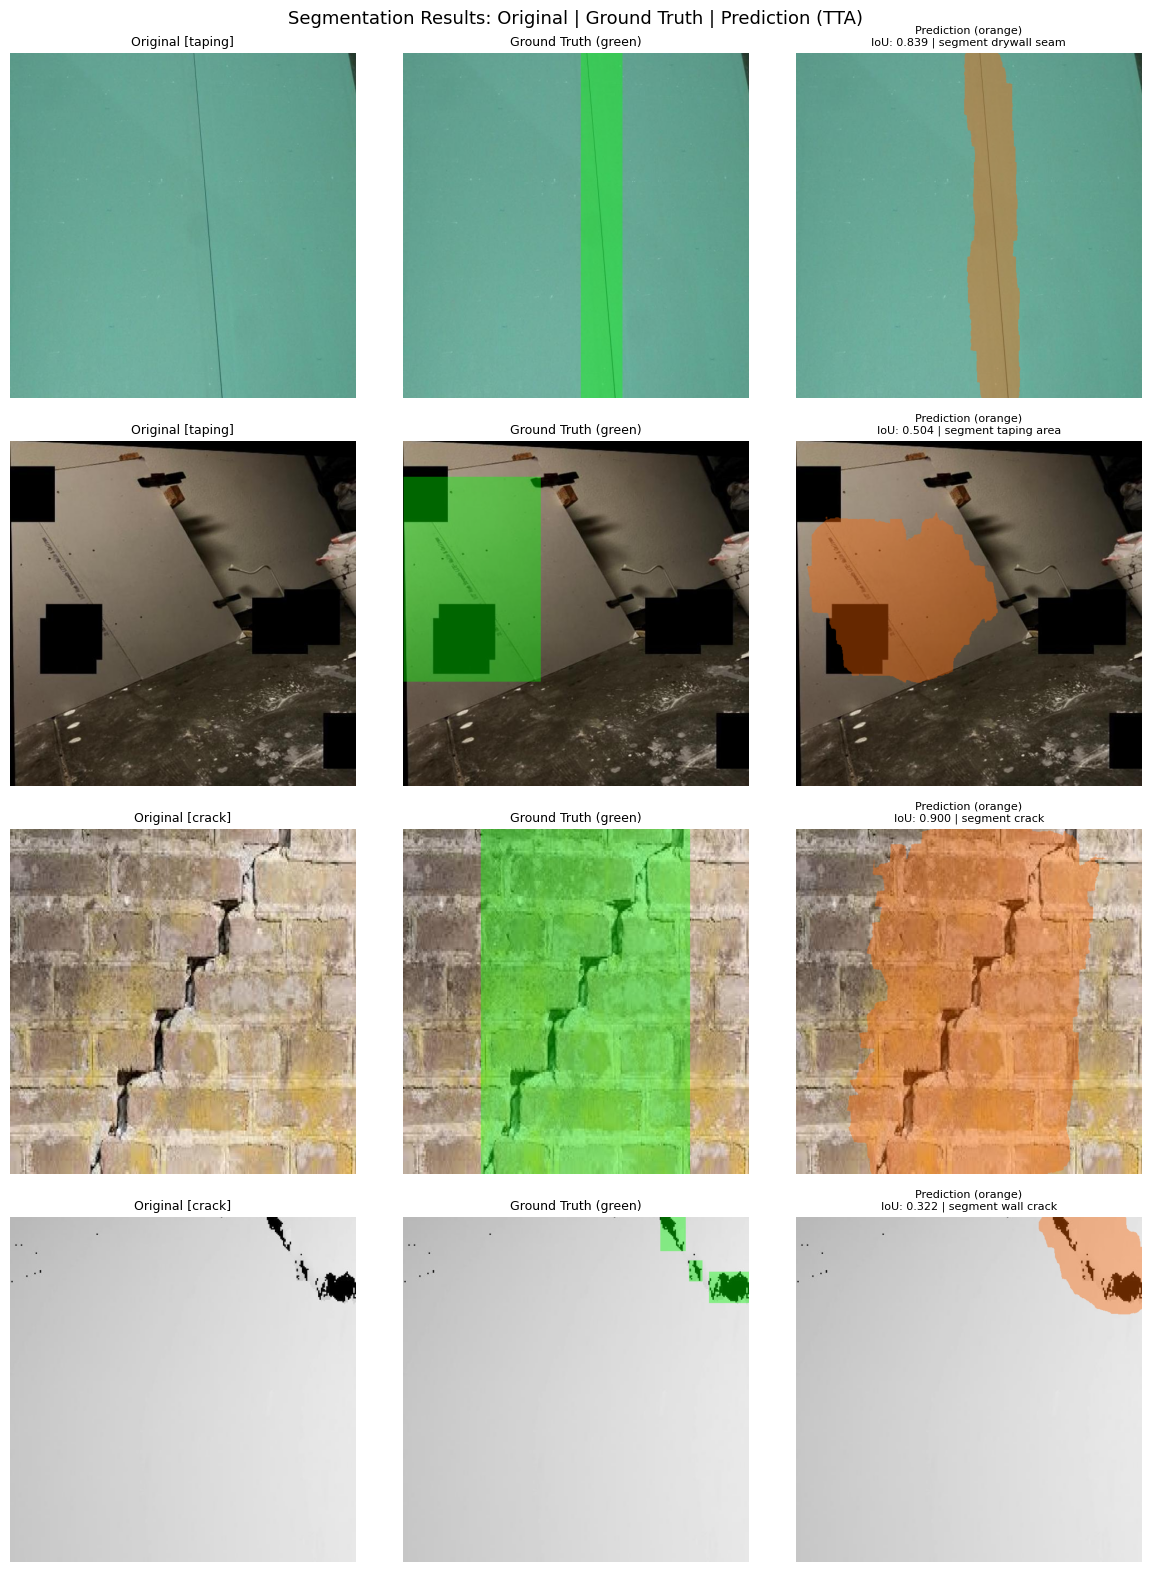

TTA visual results saved.


In [46]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch
import pandas as pd
from PIL import Image
import random

random.seed(42)

df = pd.read_csv("data/splits/master_dataset.csv")
val_df = df[df['split'] == 'val'].reset_index(drop=True)

crack_samples = val_df[val_df['dataset'] == 'crack'].sample(2, random_state=42).to_dict('records')
taping_samples = val_df[val_df['dataset'] == 'taping'].sample(2, random_state=42).to_dict('records')
samples = taping_samples + crack_samples

model.eval()
BEST_THRESHOLD = 0.35

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('Segmentation Results: Original | Ground Truth | Prediction (TTA)', fontsize=13)

with torch.no_grad():
    for i, row in enumerate(samples):
        pil_img = Image.open(row['image_path']).convert("RGB")
        orig_w, orig_h = pil_img.size
        img_np = np.array(pil_img)

        # TTA versions
        versions = [
            pil_img,
            Image.fromarray(np.fliplr(img_np)),
            Image.fromarray(np.flipud(img_np)),
            Image.fromarray(np.rot90(img_np, 1)),
        ]

        all_probs = []
        for version in versions:
            inputs = processor(
                text=[row['prompt']],
                images=[version],
                return_tensors="pt",
                padding=True
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            logits = outputs.logits[0]
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_resized = cv2.resize(probs, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
            all_probs.append(probs_resized)

        all_probs[1] = np.fliplr(all_probs[1])
        all_probs[2] = np.flipud(all_probs[2])
        all_probs[3] = np.rot90(all_probs[3], -1)

        avg_probs = np.mean(all_probs, axis=0)
        pred_mask = (avg_probs > BEST_THRESHOLD).astype(np.uint8) * 255

        gt_mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

        # Compute IoU
        gt_bin = (gt_mask > 127).astype(np.float32)
        pred_bin = (pred_mask > 127).astype(np.float32)
        intersection = (gt_bin * pred_bin).sum()
        union = ((gt_bin + pred_bin) > 0).sum()
        iou = intersection / union if union > 0 else 1.0

        # Overlays
        img_rgb = np.array(pil_img)
        gt_overlay = img_rgb.copy()
        gt_overlay[gt_mask == 255] = [0, 255, 0]
        gt_blended = cv2.addWeighted(img_rgb, 0.6, gt_overlay, 0.4, 0)

        pred_overlay = img_rgb.copy()
        pred_overlay[pred_mask == 255] = [255, 100, 0]
        pred_blended = cv2.addWeighted(img_rgb, 0.6, pred_overlay, 0.4, 0)

        axes[i][0].imshow(img_rgb)
        axes[i][0].set_title(f"Original [{row['dataset']}]", fontsize=9)
        axes[i][0].axis('off')

        axes[i][1].imshow(gt_blended)
        axes[i][1].set_title("Ground Truth (green)", fontsize=9)
        axes[i][1].axis('off')

        axes[i][2].imshow(pred_blended)
        axes[i][2].set_title(f"Prediction (orange)\nIoU: {iou:.3f} | {row['prompt']}", fontsize=8)
        axes[i][2].axis('off')

plt.tight_layout()
plt.savefig("report/figures/visual_results_tta.png", dpi=120, bbox_inches='tight')
plt.show()
print("TTA visual results saved.")